# Film Türü Oyuncu Ağı - Graf Teorisi ve Sosyal Ağ Analizi

**BİL403/503 - Sosyal Ağlar Dönem Projesi**

Bu notebook, belirli bir film türündeki (varsayılan: **Thriller**) filmlerde
birlikte oynayan oyuncular arasında bir **ortak-oynama (co-occurrence) ağı**
kurar ve bu ağ üzerinde kapsamlı graf teorisi / sosyal ağ analizi metotları
uygular.

**Veri kaynağı:** [IMDb Non-Commercial Datasets](https://developer.imdb.com/non-commercial-datasets/)
(`title.basics`, `title.principals`, `name.basics`, `title.ratings`) -
IMDb tarafından haftalık güncellenen, ücretsiz ve herkese açık ham verilerdir.

**Not:** Bu notebook, aynı klasördeki `build_graph.py` ve `graph_utils.py`
modüllerini kullanır (kod tekrarını önlemek ve `pytest` ile test edilmiş
fonksiyonları kullanmak için). Çalıştırmadan önce:
1. `pip install -r requirements.txt`
2. IMDb veri dosyalarını `data/` klasörüne indir (bkz. README.md)


## 0. Kurulum ve Import'lar

In [ ]:
%matplotlib inline
import os
import random

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import build_graph as bg
import graph_utils as gu

plt.rcParams["figure.figsize"] = (9, 6)
print("Kütüphaneler ve proje modülleri yüklendi.")


Kütüphaneler ve proje modülleri yüklendi.


## 1. Veri Toplama ve Filtreleme

Aşağıdaki parametrelerle IMDb verisinden bir film alt kümesi seçiyoruz.
Rastgele değil, **en çok IMDb oyu almış (en popüler) filmleri** seçiyoruz
(`title.ratings.tsv.gz` mevcutsa) - bu, tanınmış oyuncuların birden fazla
filmde tekrar etme ihtimalini artırarak ağın daha bağlantılı çıkmasını
sağlar.

In [2]:
GENRE = "Thriller"
MIN_YEAR = 2005
MAX_YEAR = 2024
MAX_MOVIES = 800     # popülerlik filtresiyle birlikte kullanılır
MIN_VOTES = 0        # örn. 500 yaparak çok niş yapımları eleyebilirsin
SEED = 42

movies = bg.load_filtered_movies(GENRE, MIN_YEAR, MAX_YEAR, MAX_MOVIES,
                                   min_votes=MIN_VOTES, seed=SEED)
print(f"\nSeçilen film sayısı: {len(movies)}")
movies.head()


title.basics.tsv.gz okunuyor (bu biraz zaman alabilir)...
Filtre sonrası bulunan film sayısı: 23702
UYARI: title.ratings.tsv(.gz) bulunamadı, popülerlik filtresi uygulanamıyor. Rastgele örnekleme yapılacak (daha parçalı bir ağ çıkabilir).
--max-movies ile 800 filme rastgele indirildi.

Seçilen film sayısı: 800


,tconst,titleType,primaryTitle,startYear,genres
21938,tt7741602,movie,Until Midnight,2018,"Drama,Thriller"
10250,tt21638856,movie,Creep,2022,Thriller
17693,tt4255196,movie,Before the Fire,2020,"Drama,Sci-Fi,Thriller"
649,tt0481519,movie,The Fifth Patient,2007,"Drama,Thriller,War"
7397,tt16357532,movie,Stolen Beauty,2022,Thriller


In [3]:
cast = bg.load_cast_for_movies(movies["tconst"].tolist())
name_map = bg.load_actor_names(cast["nconst"].unique().tolist())
print(f"Oyuncu-film kaydı: {len(cast)}")
print(f"Benzersiz oyuncu sayısı: {cast['nconst'].nunique()}")


title.principals.tsv.gz okunuyor (büyük dosya, sabırlı ol)...
Bulunan oyuncu-film kaydı: 6769
name.basics.tsv.gz okunuyor...
Oyuncu-film kaydı: 6769
Benzersiz oyuncu sayısı: 6491


## 2. Oyuncu-Oyuncu Ağının Kurulması

**Düğüm (node):** Oyuncu
**Kenar (edge):** İki oyuncu en az bir filmde birlikte oynamışsa
**Kenar ağırlığı:** Kaç filmde birlikte oynadıkları

Bu, aslında bir **oyuncu-film iki parçalı (bipartite) grafının projeksiyonudur**
- bkz. Bölüm 11 (Bipartite Graf) bu ilişkiyi açıkça gösterir.

In [4]:
G_full = bg.build_graph(cast, name_map)
os.makedirs("output", exist_ok=True)
nx.write_graphml(G_full, "output/actor_graph.graphml")

print(f"Graf: {G_full.number_of_nodes()} düğüm, {G_full.number_of_edges()} kenar")


Graf: 6482 düğüm, 27359 kenar


## 3. Temel Graf İstatistikleri

Ağ genelde tek parça (connected) çıkmaz - farklı filmlerin oyuncu kadroları
birbirinden bağımsız "adacıklar" oluşturabilir. Bu yüzden ileri analizler
**en büyük bağlantılı bileşen (largest connected component)** üzerinden
yapılır.

In [5]:
stats = gu.basic_stats(G_full)
for k, v in stats.items():
    print(f"{k}: {v}")

G = gu.get_largest_component(G_full)
print(f"\nEn büyük bileşen: {G.number_of_nodes()} düğüm, {G.number_of_edges()} kenar "
      f"(tüm düğümlerin %{100*G.number_of_nodes()/G_full.number_of_nodes():.1f}'i)")


n_nodes: 6482
n_edges: 27359
density: 0.001302504303634372
n_components: 616
is_connected: False

En büyük bileşen: 226 düğüm, 1097 kenar (tüm düğümlerin %3.5'i)


## 4. Derece Dağılımı

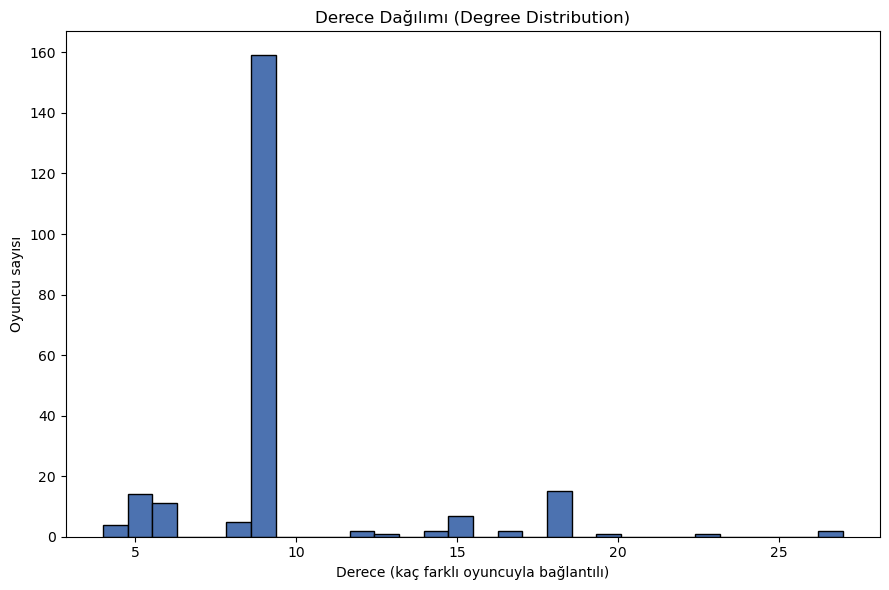

In [6]:
degrees = gu.degree_sequence(G)
plt.hist(degrees, bins=30, color="#4C72B0", edgecolor="black")
plt.title("Derece Dağılımı (Degree Distribution)")
plt.xlabel("Derece (kaç farklı oyuncuyla bağlantılı)")
plt.ylabel("Oyuncu sayısı")
plt.tight_layout()
plt.savefig("output/degree_distribution.png", dpi=150)
plt.show()


## 5. Merkezilik (Centrality) Analizleri

Beş farklı merkezilik ölçütü hesaplıyoruz; her biri "önemli" olmayı farklı
şekilde tanımlar:

| Ölçüt | Ne ölçer? | Avantaj | Dezavantaj |
|---|---|---|---|
| **Degree** | Doğrudan bağlantı sayısı | Basit, hızlı | Sadece yerel bilgi |
| **Betweenness** | Kaç en kısa yol üzerinden geçiyor ("köprü" olma) | Ağdaki kritik/aracı düğümleri bulur | Büyük ağlarda yavaş (O(nm)) |
| **Eigenvector** | Önemli düğümlerle bağlantılı olma | "Kaliteli" bağlantıyı da hesaba katar | Yıldız yapılarda kararsız olabilir |
| **Closeness** | Ortalama en kısa mesafe | Bilgi yayılım hızını temsil eder | Bağlantısız ağlarda tanımsız |
| **PageRank** | Google'ın algoritması, ağırlıklı itibar | Yönlendirilmiş/ağırlıklı ağlarda güçlü | Yorumlanması diğerlerine göre daha az sezgisel |


In [7]:
centrality = gu.centrality_measures(G)

def name_of(node):
    return G.nodes[node].get("name", node)

for metric in ["degree", "betweenness", "eigenvector", "closeness", "pagerank"]:
    print(f"\n--- En yüksek {metric} ---")
    ranked = sorted(centrality.items(), key=lambda x: x[1][metric], reverse=True)[:10]
    for node, vals in ranked:
        print(f"  {name_of(node):30s} {vals[metric]:.4f}")



--- En yüksek degree ---
  Alencier Ley Lopez             0.1200
  Joju George                    0.1200
  Manju Warrier                  0.1022
  Poonam Kaur                    0.0889
  Sathyaraj                      0.0800
  Vennela Kishore                0.0800
  S.J. Suryah                    0.0800
  Dileesh Pothan                 0.0800
  Rahul Nair                     0.0800
  Mamta Mohandas                 0.0800

--- En yüksek betweenness ---
  Jagapathi Babu                 0.4095
  S.J. Suryah                    0.3214
  Anusree                        0.2778
  Poonam Kaur                    0.2241
  Alencier Ley Lopez             0.2186
  Thambi Ramaiah                 0.2121
  Surbhi                         0.2064
  Joju George                    0.2004
  Prakash Raj                    0.1991
  V. Jayaprakash                 0.1848

--- En yüksek eigenvector ---
  Joju George                    0.3073
  Dileesh Pothan                 0.1912
  Anusree                       

In [8]:
# Tüm merkezilik skorlarını rapor/tablo için CSV'ye kaydet
rows = [{"actor": name_of(n), **v} for n, v in centrality.items()]
centrality_df = pd.DataFrame(rows).sort_values("degree", ascending=False)
centrality_df.to_csv("output/centrality_scores.csv", index=False, encoding="utf-8-sig")
centrality_df.head(10)


,actor,degree,betweenness,eigenvector,closeness,pagerank
25,Alencier Ley Lopez,0.120000,0.218571,0.144244,0.246711,0.010923
119,Joju George,0.120000,0.200376,0.307323,0.293734,0.010381
147,Manju Warrier,0.102222,0.087437,0.153968,0.249169,0.010189
204,Poonam Kaur,0.088889,0.224102,0.087469,0.300802,0.008815
33,S.J. Suryah,0.080000,0.321429,0.023554,0.232438,0.007360
51,Dileesh Pothan,0.080000,0.058124,0.191194,0.254237,0.007109
73,Mamta Mohandas,0.080000,0.088537,0.115303,0.256556,0.007184
125,Lal,0.080000,0.147857,0.056972,0.246711,0.007358
180,Balachandran Chullikadu,0.080000,0.077143,0.020541,0.202703,0.007633
70,Rahul Nair,0.080000,0.077143,0.051997,0.202703,0.007614


## 6. En Kısa Yol Örneği ("Six Degrees" testi)

In [9]:
random.seed(SEED)
a, b = random.sample(list(G.nodes()), 2)
path = gu.shortest_path_between(G, a, b)

print(f"{name_of(a)}  -->  {name_of(b)}")
print(f"Yol uzunluğu: {len(path) - 1} adım")
print(" -> ".join(name_of(n) for n in path))


Bitto Davis  -->  Baby Akshara
Yol uzunluğu: 2 adım
Bitto Davis -> Kunchacko Boban -> Baby Akshara


## 7. Louvain Topluluk Tespiti

**Louvain algoritması**, ağı modularity skorunu maksimize edecek şekilde
topluluklara ayırır. Modularity, "topluluk içi bağlantı yoğunluğu - rastgele
beklenen bağlantı yoğunluğu" farkını ölçer; 0.3 üzeri genelde anlamlı bir
topluluk yapısına işaret eder.

In [10]:
partition, modularity = gu.louvain_communities(G)
num_communities = len(set(partition.values()))
print(f"Topluluk sayısı: {num_communities}")
print(f"Modularity: {modularity:.4f}")

sizes = {}
for c in partition.values():
    sizes[c] = sizes.get(c, 0) + 1
for c, size in sorted(sizes.items(), key=lambda x: x[1], reverse=True)[:5]:
    members = [name_of(n) for n, com in partition.items() if com == c][:5]
    print(f"  Topluluk {c}: {size} kişi | örnek: {', '.join(members)}")


Topluluk sayısı: 10
Modularity: 0.8030
  Topluluk 8: 35 kişi | örnek: Vennela Kishore, Nani, Srinivas Avasarala, S.J. Suryah, Rakul Preet Singh
  Topluluk 9: 29 kişi | örnek: K.P.A.C. Lalitha, Gopalan, Sunil Annur, Dinesh Panicker, Biju Menon
  Topluluk 2: 28 kişi | örnek: Don Mathew, Shaju K.S., Ria Siara, Amina Nijam, Jinse Baskar
  Topluluk 4: 28 kişi | örnek: Soodhu Kavvum Sivakumar, Eshanya Maheshwari, Jeeva Rathnam, Raghav Umasrinivasan, John Vijay
  Topluluk 7: 21 kişi | örnek: Mahesh Kumar Longa, Deepa Iyer, Adi Lokesh, Pooja Gandhi, Ritiksha


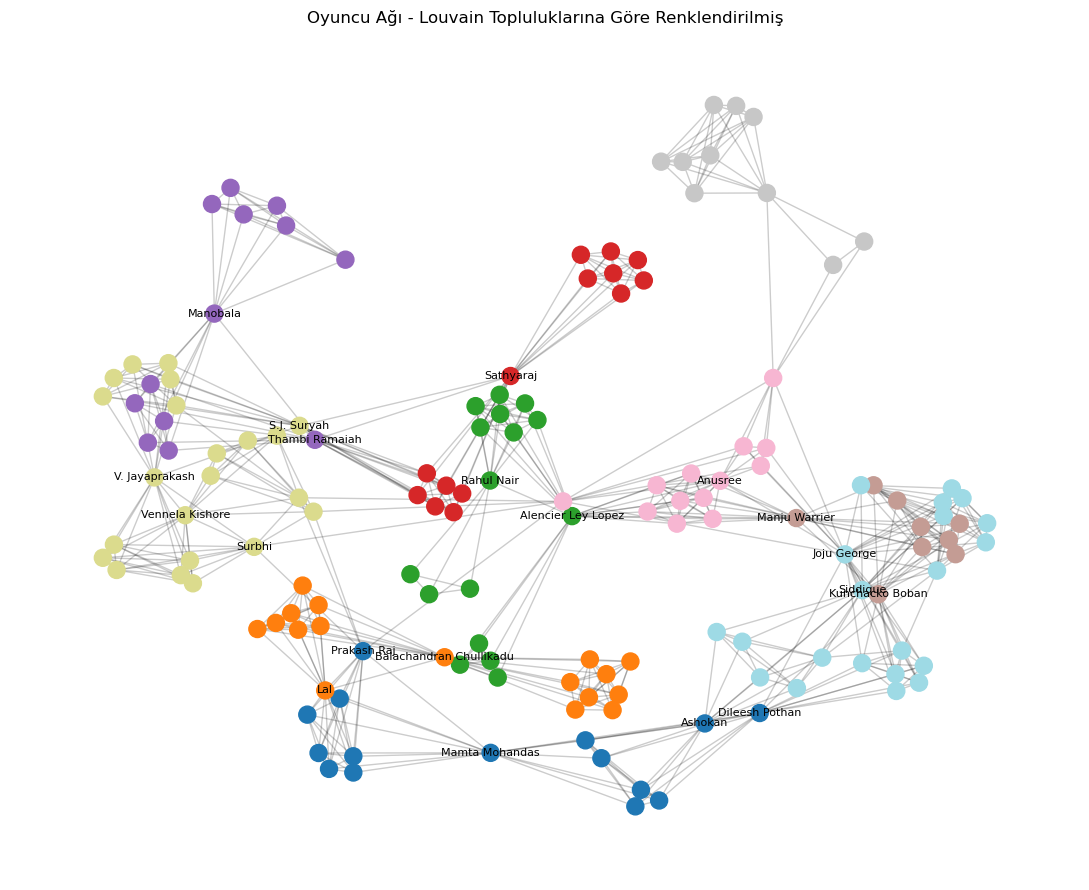

In [11]:
def plot_communities(G, partition, max_nodes=150):
    if G.number_of_nodes() > max_nodes:
        top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:max_nodes]
        H = G.subgraph([n for n, _ in top_nodes]).copy()
    else:
        H = G
    pos = nx.spring_layout(H, seed=SEED, k=0.3)
    colors = [partition[n] for n in H.nodes()]
    plt.figure(figsize=(11, 9))
    nx.draw_networkx_edges(H, pos, alpha=0.2)
    nx.draw_networkx_nodes(H, pos, node_color=colors, cmap=plt.cm.tab20, node_size=150)
    top_labels = sorted(H.degree, key=lambda x: x[1], reverse=True)[:20]
    nx.draw_networkx_labels(H, pos, labels={n: name_of(n) for n, _ in top_labels}, font_size=8)
    plt.title("Oyuncu Ağı - Louvain Topluluklarına Göre Renklendirilmiş")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("output/communities.png", dpi=150)
    plt.show()

plot_communities(G, partition)


## 8. Kümelenme Katsayısı, Çap ve Asortativite

- **Kümelenme katsayısı**: "arkadaşlarımın da birbirini tanıma olasılığı"
- **Çap (diameter)**: ağdaki en uzak iki düğüm arasındaki mesafe
- **Asortativite**: yüksek dereceli düğümler birbirine mi bağlanıyor?

In [12]:
clustering = gu.clustering_metrics(G)
path_m = gu.path_metrics(G)
assort = gu.assortativity(G)

print(f"Ortalama kümelenme katsayısı: {clustering['average_clustering']:.4f}")
print(f"Transitivity (global kümelenme): {clustering['transitivity']:.4f}")
print(f"Çap: {path_m['diameter']} adım")
print(f"Ortalama en kısa yol: {path_m['avg_shortest_path_length']:.2f} adım")
print(f"Derece asortativitesi: {assort:.4f}")


Ortalama kümelenme katsayısı: 0.4622
Transitivity (global kümelenme): 0.7568
Çap: 11 adım
Ortalama en kısa yol: 4.93 adım
Derece asortativitesi: -0.0222


## 9. Kesme Noktaları (Articulation Points)

Bu oyuncular çıkarılırsa ağ birden fazla parçaya bölünür - yani ağın
yapısal olarak en "kritik" noktalarıdır.

In [13]:
articulation_points = gu.find_articulation_points(G)
print(f"Toplam kesme noktası: {len(articulation_points)}")
for p in articulation_points[:15]:
    print(f"  - {name_of(p)}")


Toplam kesme noktası: 13
  - Balachandran Chullikadu
  - Lal
  - Pooja Gandhi
  - Makrand Deshpande
  - Rahul Nair
  - Alencier Ley Lopez
  - Manju Warrier
  - Sathyaraj
  - Arundhathi
  - Mayilsamy
  - Manobala
  - Thambi Ramaiah
  - S.J. Suryah


## 10. Ağ Dayanıklılık (Robustness) Testi

En merkezi oyuncuları sırayla çıkarırsak (**hedefli saldırı**) ağ ne kadar
hızlı çöker? Bunu **rastgele arıza** senaryosuyla karşılaştırıyoruz. Bu,
sosyal ağların "hedefli saldırılara kırılgan, rastgele arızalara dayanıklı"
olduğu bilinen özelliğinin klasik bir gösterimidir (Albert, Jeong & Barabási,
2000).

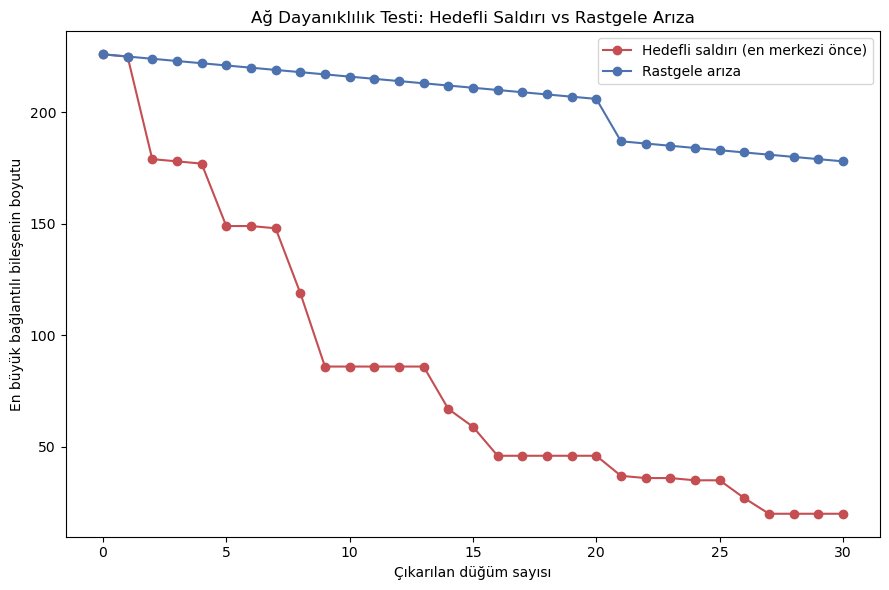

In [14]:
max_removals = min(30, G.number_of_nodes() - 2)
targeted = gu.robustness_simulation(G, centrality, metric="betweenness", max_removals=max_removals)
random_fail = gu.random_failure_simulation(G, seed=SEED, max_removals=max_removals)

x_t, y_t = zip(*targeted)
x_r, y_r = zip(*random_fail)

plt.plot(x_t, y_t, marker="o", label="Hedefli saldırı (en merkezi önce)", color="#C44E52")
plt.plot(x_r, y_r, marker="o", label="Rastgele arıza", color="#4C72B0")
plt.xlabel("Çıkarılan düğüm sayısı")
plt.ylabel("En büyük bağlantılı bileşenin boyutu")
plt.title("Ağ Dayanıklılık Testi: Hedefli Saldırı vs Rastgele Arıza")
plt.legend()
plt.tight_layout()
plt.savefig("output/robustness_test.png", dpi=150)
plt.show()


## 11. En Merkezi Oyuncunun Ego Ağı

En merkezi oyuncu: Alencier Ley Lopez
Ego ağı: 28 düğüm, 135 kenar


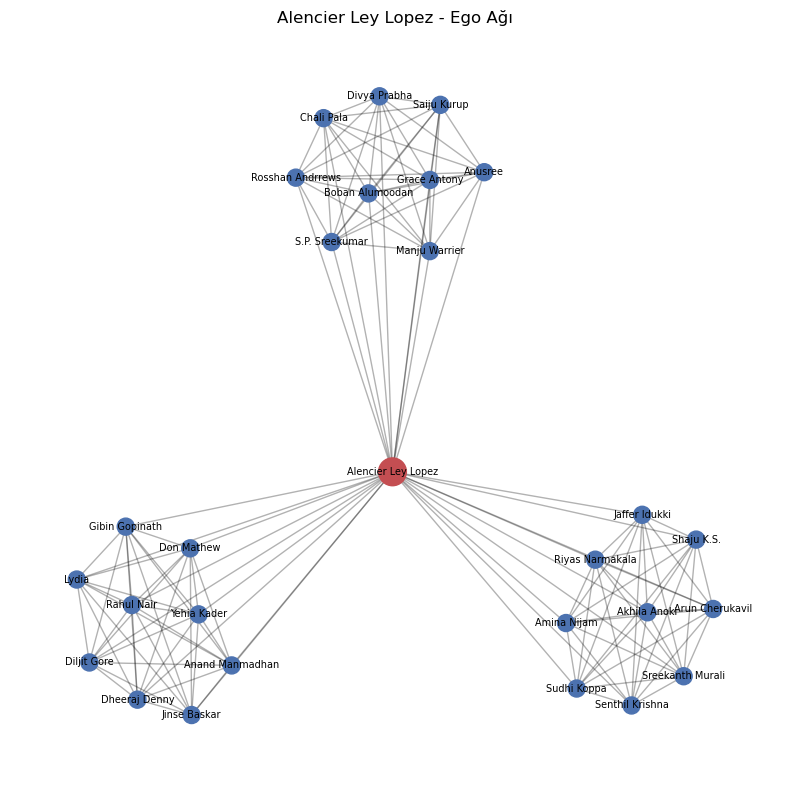

In [15]:
top_actor = max(centrality.keys(), key=lambda n: centrality[n]["degree"])
ego = gu.ego_network(G, top_actor, radius=1)
print(f"En merkezi oyuncu: {name_of(top_actor)}")
print(f"Ego ağı: {ego.number_of_nodes()} düğüm, {ego.number_of_edges()} kenar")

pos = nx.spring_layout(ego, seed=SEED)
colors = ["#C44E52" if n == top_actor else "#4C72B0" for n in ego.nodes()]
sizes = [400 if n == top_actor else 150 for n in ego.nodes()]
plt.figure(figsize=(8, 8))
nx.draw_networkx_edges(ego, pos, alpha=0.3)
nx.draw_networkx_nodes(ego, pos, node_color=colors, node_size=sizes)
nx.draw_networkx_labels(ego, pos, labels={n: name_of(n) for n in ego.nodes()}, font_size=7)
plt.title(f"{name_of(top_actor)} - Ego Ağı")
plt.axis("off")
plt.tight_layout()
plt.savefig("output/ego_network.png", dpi=150)
plt.show()


## 12. Link Prediction (Basit Öneri Sistemi)

Henüz birlikte oynamamış ama çok sayıda ortak film arkadaşı (ortak komşusu)
olan oyuncu çiftlerini buluyoruz - "gelecekte birlikte çalışması beklenebilecek"
isimler.

In [16]:
predictions = gu.common_neighbor_link_predictions(G, top_n=10)
for u, v, common in predictions:
    print(f"  {name_of(u):25s} <-> {name_of(v):25s}   ortak bağlantı: {common}")


  Vennela Kishore           <-> Narsing Yadav               ortak bağlantı: 3
  Vennela Kishore           <-> Jagapathi Babu              ortak bağlantı: 3
  Vennela Kishore           <-> Naveen Vadde                ortak bağlantı: 3
  Vennela Kishore           <-> Prakash Raj                 ortak bağlantı: 3
  Nani                      <-> Surbhi                      ortak bağlantı: 3
  Surbhi                    <-> Bhupal                      ortak bağlantı: 3
  Surbhi                    <-> Allari Naresh               ortak bağlantı: 3
  Surbhi                    <-> Aadarsh Balakrishna         ortak bağlantı: 3
  Surbhi                    <-> Tejaswini Lonari            ortak bağlantı: 3
  Surbhi                    <-> Shraddha Das                ortak bağlantı: 3


## 13. Küçük-Dünya (Small-World) Testi

Ağı, aynı düğüm/kenar sayısına sahip rastgele graflarla karşılaştırıyoruz.
**Sigma (σ) > 1** ise ağ "küçük-dünya" özelliği taşıyor demektir: yüksek
kümelenme + kısa ortalama yol uzunluğu bir arada (Watts & Strogatz, 1998 -
ilginç şekilde bu makalenin kendisi de bir *film-oyuncu işbirliği ağını*
örnek olarak kullanmıştı).

In [17]:
sw = gu.small_world_metrics(G, n_random=15, seed=SEED)
print(f"Gerçek ağ  -> kümelenme: {sw['C_actual']:.4f} | ort. yol: {sw['L_actual']:.4f}")
print(f"Rastgele ağ -> kümelenme: {sw['C_random_avg']:.4f} | ort. yol: {sw['L_random_avg']:.4f}")
print(f"\nSigma (σ) = {sw['sigma']:.3f}")
print("Küçük-dünya özelliği: " + ("VAR (σ>1)" if sw["sigma"] and sw["sigma"] > 1 else "belirgin değil"))


Gerçek ağ  -> kümelenme: 0.7568 | ort. yol: 4.9324
Rastgele ağ -> kümelenme: 0.0413 | ort. yol: 2.6239

Sigma (σ) = 9.737
Küçük-dünya özelliği: VAR (σ>1)


## 14. Klik (Clique) Analizi

Bir "klik", herkesin herkesle bağlı olduğu bir alt gruptur. Film ağlarında
her klik genelde tek bir filmin (veya üst üste aynı kadroyla çekilmiş
filmlerin) oyuncularına karşılık gelir.

Toplam maksimal klik sayısı: 32
En büyük klik boyutu: 10
  1. (10 kişi) Prithviraj Sukumaran, Jinu Joseph, Lal, Assim Jamal, Prakash Raj, Sudheer Karamana, Sampath Raj, Nithya Menen, Molly Kannamaly, Mamta Mohandas
  2. (10 kişi) Rahul Karthik, Lal, Govind Padmasoorya, Arjun Nandakumar, Gowri, Sasha Gopinath, Miya George, Balachandran Chullikadu, P. Balachandran, Sasi Kalinga
  3. (10 kişi) Praveena, Ashokan, Nisthar Sait, Vijayaraghavan, Sphadikam George, Soubin Shahir, Sharafudheen, Dileesh Pothan, Fahadh Faasil, Mamta Mohandas
  4. (10 kişi) Sathyaraj, Azhagam Perumal, 'Ganja' Karuppu, Gibran Osman, S.J. Suryah, Monali Sehgal, Thambi Ramaiah, Sharad K.R.G., Sulagna Panigrahi, Raju Sundaram
  5. (10 kişi) Sathyaraj, Madhusudhan Rao, Lollu Sabha Manohar, Faheem, Charlie, Lissy Antony, Gajaraj, Kalairasan, Lizzie Antony, Smruthi Venkat


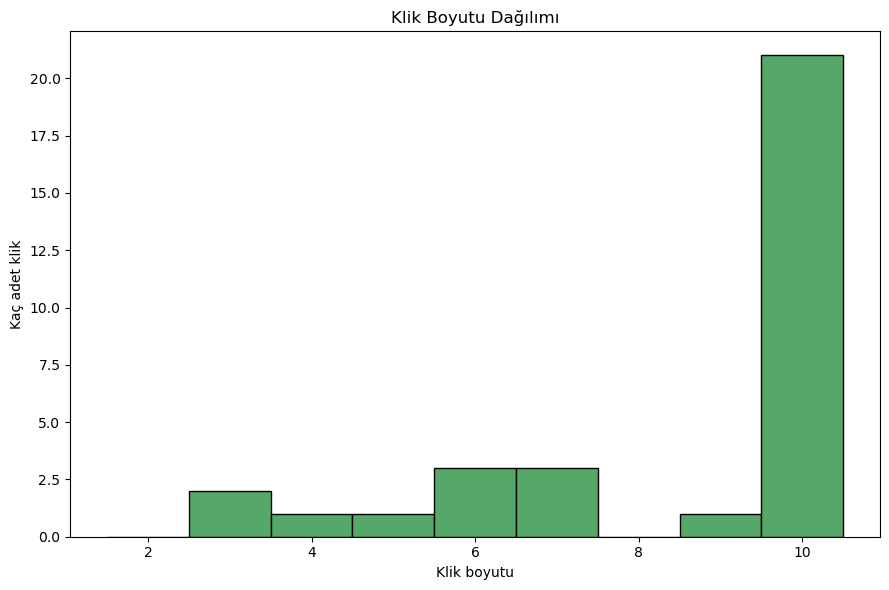

In [18]:
cliques = gu.clique_analysis(G, top_n=5)
print(f"Toplam maksimal klik sayısı: {cliques['n_cliques']}")
print(f"En büyük klik boyutu: {cliques['largest_clique_size']}")
for i, c in enumerate(cliques["top_cliques"], start=1):
    print(f"  {i}. ({len(c)} kişi) {', '.join(name_of(n) for n in c)}")

plt.hist(cliques["size_distribution"],
          bins=range(2, cliques["largest_clique_size"] + 2),
          color="#55A868", edgecolor="black", align="left")
plt.title("Klik Boyutu Dağılımı")
plt.xlabel("Klik boyutu")
plt.ylabel("Kaç adet klik")
plt.tight_layout()
plt.savefig("output/clique_distribution.png", dpi=150)
plt.show()


## 15. K-Core Ayrıştırması

Ağın en "sıkı bağlı" çekirdek kısmını bulur: bir düğümün k-core değeri, en
az k dereceye sahip olduğu en büyük alt grafın parçası olduğu k'dır.

In [19]:
kcore = gu.k_core_analysis(G)
print(f"Maksimum k-core: {kcore['max_k']}")
print(f"Ana çekirdek boyutu: {kcore['main_core_size']} oyuncu")
for n in kcore["main_core_nodes"][:15]:
    print(f"  - {name_of(n)}")


Maksimum k-core: 9
Ana çekirdek boyutu: 190 oyuncu
  - Prithviraj Sukumaran
  - Rahul Karthik
  - Don Mathew
  - Praveena
  - Sathyaraj
  - Joy Badlani
  - Resmi Boban
  - Divya Prabha
  - Mahesh Kumar Longa
  - Shaju K.S.
  - Ria Siara
  - Vennela Kishore
  - Lollu Sabha Manohar
  - Eshanya Maheshwari
  - Amina Nijam


## 16. Bipartite (Oyuncu-Film) Graf ve Projeksiyon

Bu bölüm, projenin başından beri kullandığımız oyuncu-oyuncu ağının aslında
NASIL türetildiğini gösterir: önce iki farklı düğüm tipine sahip bir
**bipartite graf** (Oyuncular + Filmler) kurulur, sonra bu graf oyuncu-oyuncu
ağına **projekte edilir**. Aşağıda bu iki yöntemin (doğrudan vs. bipartite
projeksiyon) birebir aynı sonucu verdiğini doğruluyoruz.

In [20]:
B, actor_nodes, movie_nodes = gu.build_bipartite_graph(cast, name_map)
print(f"Bipartite graf: {len(actor_nodes)} oyuncu, {len(movie_nodes)} film, {B.number_of_edges()} kenar")

projected = gu.project_bipartite(B, actor_nodes)
direct_edges = {frozenset(e) for e in G_full.edges()}
projected_edges = {frozenset(e) for e in projected.edges()}
print(f"İki yöntem tutarlı mı? {'EVET' if direct_edges == projected_edges else 'HAYIR'}")


Bipartite graf: 6491 oyuncu, 782 film, 6669 kenar
İki yöntem tutarlı mı? EVET


## 17. Sonuç Özeti

Bu notebook'ta:
1. IMDb verisinden popülerlik-ağırlıklı bir oyuncu ağı kurduk
2. Beş farklı merkezilik ölçütüyle "önemli" oyuncuları tespit ettik
3. Louvain ile topluluk yapısını çıkardık
4. Ağın küçük-dünya, klik ve k-core özelliklerini formal olarak test ettik
5. Hedefli saldırı / rastgele arıza karşılaştırmasıyla ağın dayanıklılığını ölçtük
6. Bipartite projeksiyon ile yöntem tutarlılığını doğruladık
